 ## Build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

In [318]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# importing the dataset


In [319]:
df=pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Finding if there are any Missing values in the dataset, columnwise 

In [320]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [321]:
df[df["Cabin"].isna()]
## Since it has very low correlation and it has no impact to the prediction due to its highly diverse values, we just drop it.
df.drop('Cabin',axis=1,inplace=True)

 Embarked column indicates the port where each passenger boarded the ship. It uses single-letter codes:

S → Southampton, England

C → Cherbourg, France

Q → Queenstown (now Cobh), Ireland

These values are important because they can sometimes correlate with survival rates and passenger demographics.

In [322]:
df[df["Embarked"].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,NaN


In [323]:
#Since only two values are NAN so we just drop it
df.drop(df[df["Embarked"].isna()].index, inplace=True)
df.head()
#OR the actual correct way of handling this is to fill it with the mode value as its a categorical value 
#df['Embarked'].fillna('S',inplace=True)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [324]:
df['Title']=df['Name'].str.split(", ",expand=True)[1].str.split(".",expand=True)[0]
df['Title'].value_counts()

Title
Mr              517
Miss            181
Mrs             124
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [325]:
df['Title'] = df['Title'].replace(['Lady', 'the Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
df['Title'].value_counts()

Title
Mr        517
Miss      184
Mrs       125
Master     40
Rare       23
Name: count, dtype: int64

In [326]:
df[df["Age"].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,Q,Mr
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,S,Mr
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,C,Mrs
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,C,Mr
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,Q,Miss
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,C,Mr
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,S,Miss
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,S,Mr
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,S,Mr


In [327]:
# df['Age']=df.groupby(['Sex','Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
#the above is a simple yet above average method
# Since the Age feature is highly correlated to the final survival target value, we need some good imputation methods
#So, although a little slower I have chosen to use KNN Imputation so that the imputed values are more accurate

# “Find similar passengers and copy their age.” 
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df[['Age']] = imputer.fit_transform(df[['Age','Pclass','Fare']])[:,0].reshape(-1,1)
df["Age"].isna().sum()

np.int64(0)

In [328]:
df['Family_size']=df['Parch']+df['SibSp']
df.drop(['Parch','SibSp','Fare','Ticket','Name'],axis=1,inplace=True)
df.head()

,PassengerId,Survived,Pclass,Sex,Age,Embarked,Title,Family_size
0,1,0,3,male,22.0,S,Mr,1
1,2,1,1,female,38.0,C,Mrs,1
2,3,1,3,female,26.0,S,Miss,0
3,4,1,1,female,35.0,S,Mrs,1
4,5,0,3,male,35.0,S,Mr,0


In [329]:
df['Age_Class'] = ((df['Age'] // 10) + 1).astype('Int64')
df[df['Age_Class']==9]


,PassengerId,Survived,Pclass,Sex,Age,Embarked,Title,Family_size,Age_Class
630,631,1,1,male,80.0,S,Mr,0,9


In [330]:
print((df['Age_Class']==9).sum())


1


In [331]:
#Since it is the only entry that falls in the Age_Class bin= 9
#It is acting as an outlier negatively influencing the correlation analysis, so we just drop it.
df.drop(index=630,inplace=True)
(df['Age_Class']==9).sum()

np.int64(0)

In [332]:
col=['Embarked','Pclass','Sex','Age_Class','Title','Family_size']
for i in col:
    print('Survival Correlation by:', i)
    df2=df.groupby(i)['Survived'].mean().reset_index()
    print(df2)
    print('-'*25, '\n')

Survival Correlation by: Embarked
  Embarked  Survived
0        C  0.553571
1        Q  0.389610
2        S  0.335925
------------------------- 

Survival Correlation by: Pclass
   Pclass  Survived
0       1  0.624413
1       2  0.472826
2       3  0.242363
------------------------- 

Survival Correlation by: Sex
      Sex  Survived
0  female  0.740385
1    male  0.187500
------------------------- 

Survival Correlation by: Age_Class
   Age_Class  Survived
0          1  0.603175
1          2  0.413462
2          3  0.313665
3          4  0.418182
4          5  0.371429
5          6  0.420000
6          7  0.277778
7          8  0.000000
------------------------- 

Survival Correlation by: Title
    Title  Survived
0  Master  0.575000
1    Miss  0.701087
2      Mr  0.155039
3     Mrs  0.792000
4    Rare  0.347826
------------------------- 

Survival Correlation by: Family_size
   Family_size  Survived
0            0  0.299625
1            1  0.552795
2            2  0.578431
3          

In [333]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
Embarked       0
Title          0
Family_size    0
Age_Class      0
dtype: int64

Data is successfully cleaned and next step is to analyse the data.

In [334]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 888 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  888 non-null    int64  
 1   Survived     888 non-null    int64  
 2   Pclass       888 non-null    int64  
 3   Sex          888 non-null    object 
 4   Age          888 non-null    float64
 5   Embarked     888 non-null    object 
 6   Title        888 non-null    object 
 7   Family_size  888 non-null    int64  
 8   Age_Class    888 non-null    Int64  
dtypes: Int64(1), float64(1), int64(4), object(3)
memory usage: 70.2+ KB


In [335]:
#label encoding all the categorical values
df_encoded=df.copy()
df_encoded['Sex']=df_encoded['Sex'].map({'male':1,'female':2})
df_encoded['Embarked']=df_encoded['Embarked'].map({'S':1,'C':2,'Q':3})
df_encoded['Title']=df_encoded['Title'].astype('category').cat.codes


In [336]:
Pearson_corr=df_encoded.corr('pearson')
print(Pearson_corr)

             PassengerId  Survived    Pclass       Sex       Age  Embarked  \
PassengerId     1.000000 -0.006066 -0.034112 -0.042565  0.031584 -0.030107   
Survived       -0.006066  1.000000 -0.334068  0.543297 -0.072752  0.109604   
Pclass         -0.034112 -0.334068  1.000000 -0.129262 -0.358341  0.042894   
Sex            -0.042565  0.543297 -0.129262  1.000000 -0.088306  0.118178   
Age             0.031584 -0.072752 -0.358341 -0.088306  1.000000  0.023244   
Embarked       -0.030107  0.109604  0.042894  0.118178  0.023244  1.000000   
Title           0.074865 -0.072069 -0.181562 -0.060849  0.465788 -0.090508   
Family_size    -0.039821  0.019102  0.063325  0.202824 -0.228525 -0.081447   
Age_Class       0.033010 -0.065484 -0.361829 -0.086096  0.975539  0.016994   

                Title  Family_size  Age_Class  
PassengerId  0.074865    -0.039821   0.033010  
Survived    -0.072069     0.019102  -0.065484  
Pclass      -0.181562     0.063325  -0.361829  
Sex         -0.060849     0

In [337]:
# Calculating the correlation and plotting the correlation heatmap
Spearman_corr=df_encoded.corr('spearman')
print(Spearman_corr)

             PassengerId  Survived    Pclass       Sex       Age  Embarked  \
PassengerId     1.000000 -0.005991 -0.033169 -0.042514  0.038099 -0.025347   
Survived       -0.005991  1.000000 -0.335529  0.543297 -0.041215  0.138880   
Pclass         -0.033169 -0.335529  1.000000 -0.133370 -0.343676 -0.007522   
Sex            -0.042514  0.543297 -0.133370  1.000000 -0.074606  0.122119   
Age             0.038099 -0.041215 -0.343676 -0.074606  1.000000  0.025224   
Embarked       -0.025347  0.138880 -0.007522  0.122119  0.025224  1.000000   
Title           0.070970 -0.081373 -0.160373 -0.116823  0.411019 -0.086367   
Family_size    -0.049948  0.169302 -0.079722  0.294704 -0.195034 -0.021931   
Age_Class       0.040901 -0.041704 -0.352667 -0.070606  0.966259  0.026638   

                Title  Family_size  Age_Class  
PassengerId  0.070970    -0.049948   0.040901  
Survived    -0.081373     0.169302  -0.041704  
Pclass      -0.160373    -0.079722  -0.352667  
Sex         -0.116823     0

### “Spearman is useful here because many features are ordinal and relationships may be monotonic rather than linear.”
I chose the Spearman Correlation, here's the explaination
- So when analyzing survival against features like class, age groups, or family size, Spearman is often more appropriate because:
- It doesn’t assume linearity.
- It respects the rank order of categories.
- It captures monotonic trends (e.g., “higher class → higher survival”) even if the relationship isn’t a straight line.

<Axes: >

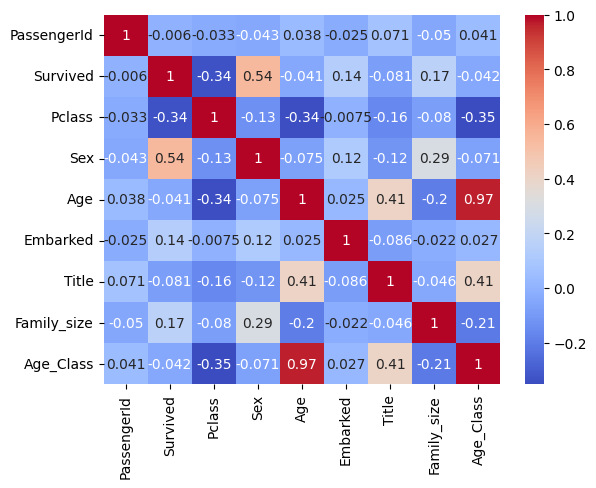

In [338]:
sns.heatmap(Spearman_corr, annot=True, cmap='coolwarm')

In [339]:
# Removing useless and redundant features
df.drop(['Age','PassengerId'],axis=1,inplace=True)
df.head()

,Survived,Pclass,Sex,Embarked,Title,Family_size,Age_Class
0,0,3,male,S,Mr,1,3
1,1,1,female,C,Mrs,1,4
2,1,3,female,S,Miss,0,3
3,1,1,female,S,Mrs,1,4
4,0,3,male,S,Mr,0,4


### “Low correlation does NOT mean useless — especially for classification models like Naive Bayes.”

In [340]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.naive_bayes import GaussianNB
df_encoded.head()

,PassengerId,Survived,Pclass,Sex,Age,Embarked,Title,Family_size,Age_Class
0,1,0,3,1,22.0,1,2,1,3
1,2,1,1,2,38.0,2,3,1,4
2,3,1,3,2,26.0,1,1,0,3
3,4,1,1,2,35.0,1,3,1,4
4,5,0,3,1,35.0,1,2,0,4


In [341]:
X=df_encoded.drop('Survived',axis=1)
X.head()

,PassengerId,Pclass,Sex,Age,Embarked,Title,Family_size,Age_Class
0,1,3,1,22.0,1,2,1,3
1,2,1,2,38.0,2,3,1,4
2,3,3,2,26.0,1,1,0,3
3,4,1,2,35.0,1,3,1,4
4,5,3,1,35.0,1,2,0,4


In [342]:
y=df_encoded['Survived']
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [343]:

#Train test split of 90-10
X1_train,X1_test,y1_train,y1_test=train_test_split(X,y,test_size=0.1,random_state=93,stratify=y)
#Training a Gaussian Naive Bayes ML Model
model_gb1=GaussianNB()
model_gb1.fit(X1_train,y1_train)
#Test/Prediction
y_pred1=model_gb1.predict(X1_test)
print(f"Accuracy:{ accuracy_score(y1_test, y_pred1):.2f}")
print(f"F1_Score:{f1_score(y1_test, y_pred1,average="weighted"):.2f}")


Accuracy:0.83
F1_Score:0.83


In [344]:

#Train test split of 70-30
X2_train,X2_test,y2_train,y2_test=train_test_split(X,y,test_size=0.3,random_state=31)
model_gb2=GaussianNB()
model_gb2.fit(X2_train,y2_train)
#Test/Prediction
y_pred2=model_gb2.predict(X2_test)
print(f"Accuracy:{ accuracy_score(y2_test, y_pred2):.2f}")
print(f"F1_Score:{f1_score(y2_test, y_pred2,average="weighted"):.2f}")


Accuracy:0.78
F1_Score:0.78



A BETTER ALTERNATIVE APPROACH TO SIMPLE TRAIN_TEST_SPLIT


In [345]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=93,
    stratify=y
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=93)

model = GaussianNB()

cv_acc = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
cv_f1  = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1_weighted')

print(f"CV Accuracy: {np.mean(cv_acc):.2f}")
print(f"CV F1 Score: {np.mean(cv_f1):.2f}")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Test F1 Score: {f1_score(y_test, y_pred, average='weighted'):.2f}")

CV Accuracy: 0.81
CV F1 Score: 0.81
Test Accuracy: 0.83
Test F1 Score: 0.83
